# Comment Category Prediction Challenge

**Problem Statement**

The goal of this project is to predict the category of user comments based on their content and additional metadata.

**Objective**

Build a machine learning model that can accurately classify comments into categories using text and other features.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "/kaggle/input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you save and run
# If you prefer, you can use temporary scratch space. It doesn't get preserved. Use at most 20GB.
# You can also write to /tmp which is temporary

/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv
/kaggle/input/competitions/comment-category-prediction-challenge/train.csv
/kaggle/input/competitions/comment-category-prediction-challenge/test.csv


# Section 1: Imports & Setup


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

**Insight:**
Here we're loading all the tools we'll need throughout the notebook:
- numpy and pandas are used for data handling and manipulation.
- matplotlib and seaborn are used for data visualization (plots/graphs).
- train_test_split is used to divide data into training and testing sets.
- TfidfVectorizer is used to convert text into numerical features.
- StandardScaler is used to normalize/scale numerical data.
- hstack and csr_matrix help to combine and handle sparse data (like text features).

# Section 2: Data Loading

In [3]:
DATA_PATH = '/kaggle/input/competitions/comment-category-prediction-challenge'

train = pd.read_csv(f'{DATA_PATH}/train.csv')
test  = pd.read_csv(f'{DATA_PATH}/test.csv')

print('Train shape:', train.shape)
print('Test shape:', test.shape)

train.head()

Train shape: (198000, 15)
Test shape: (102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


**Insight:** 
We read the CSV files into our notebook. The output tells us:

Train data: 198,000 rows, 15 columns (this includes the label we want to predict)
Test data: 102,000 rows, 14 columns (no label that's what we need to predict).

The first few rows show us what the data looks like comments with information like when they were posted, how many upvotes/downvotes they got, emoticons used, and the actual comment text.

# Section 3: Exploratory Data Analysis (EDA)

In [4]:
#dataset information
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


**Insight:**
This gives us a full summary of the dataset. Key things we notice:
- Most columns have 198,000 values, but race, religion, and gender only have about 52,577 non-null values meaning around 73% of those columns are missing (NaN). So they may not be very useful.
- The label ranges from 0 to 3, with an average of about 0.79, meaning most comments fall into label 0. so the dataset is imbalanced.

**Missing values count**

In [5]:
# missing values count
print("Missing Values in Training Data")

train_missing = train.isna().sum()
train_missing = train_missing[train_missing != 0]
print(train_missing)

print("Missing Values in Test Data")

test_missing = test.isna().sum()
test_missing = test_missing[test_missing != 0]

print(test_missing)

Missing Values in Training Data
race        145423
religion    145423
gender      145423
comment          1
dtype: int64
Missing Values in Test Data
race        75269
religion    75269
gender      75269
dtype: int64


**Insight:**
- The code is counting missing (NaN) values in train and test data.
- It only shows columns where missing values exist.
race, religion, gender have very high missing values means they not reliable.
- comment has only 1 missing value means it is almost complete and useful.
- Same missing pattern in both train and test data collection issue (systematic).

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64
label
0    57.66
2    31.54
1     8.04
3     2.76
Name: proportion, dtype: float64


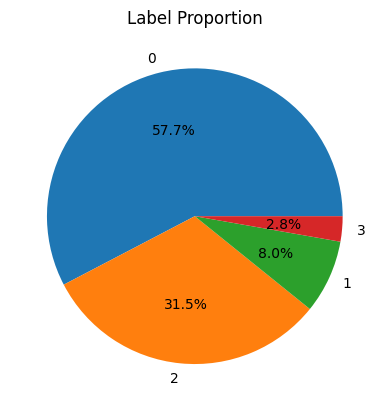

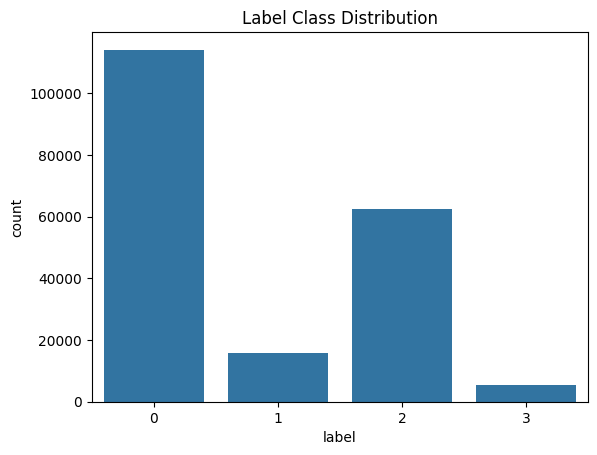

In [6]:
# Label Distribution

print(train['label'].value_counts())
print((train['label'].value_counts(normalize=True) * 100).round(2))

train['label'].value_counts(normalize=True).plot.pie(autopct='%1.1f%%')

plt.title("Label Proportion")
plt.ylabel("")
plt.show()
sns.countplot(x='label', data=train)
plt.title("Label Class Distribution")
plt.show()

**Insights**
- The bar graph shows that label 0 has the highest number of samples, much taller than others.
- Label 2 is the second largest group, but still clearly smaller than label 0.
- Labels 1 and 3 have very low counts, especially label 3 which is the smallest.
- The pie chart confirms the same pattern:
    - Label 0 covers more than half of the data (around 57.7%).
    - Label 2 takes about 31.5%.
    - Label 1 and 3 together form a very small portion.
- This clearly shows the dataset is highly imbalanced, meaning some classes dominate while others have very little data.

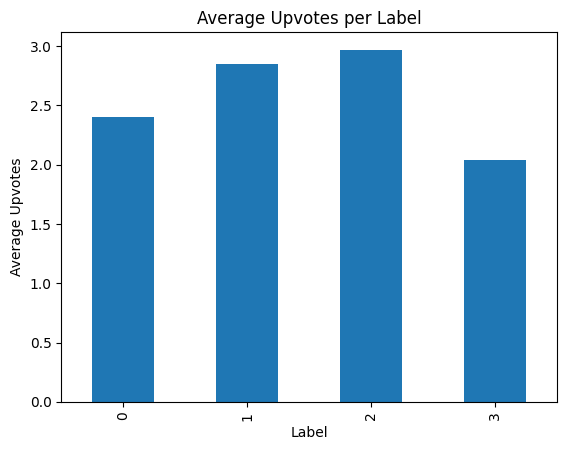

In [7]:
# Average upvotes per label
train.groupby('label')['upvote'].mean().plot.bar()

plt.title("Average Upvotes per Label")
plt.xlabel("Label")
plt.ylabel("Average Upvotes")
plt.show()

**Insights**
- The graph shows average upvotes for each label.
- Label 2 has the highest average upvotes, so it gets the most engagement.
- Label 1 also has relatively high upvotes, slightly less than label 2.
- Label 0 has moderate upvotes.
- Label 3 has the lowest average upvotes, meaning least engagement.

This means not all labels are equally popular, some get more attention than others.
The graph shows that different labels receive different levels of engagement, with some labels getting higher average upvotes while others receive less.

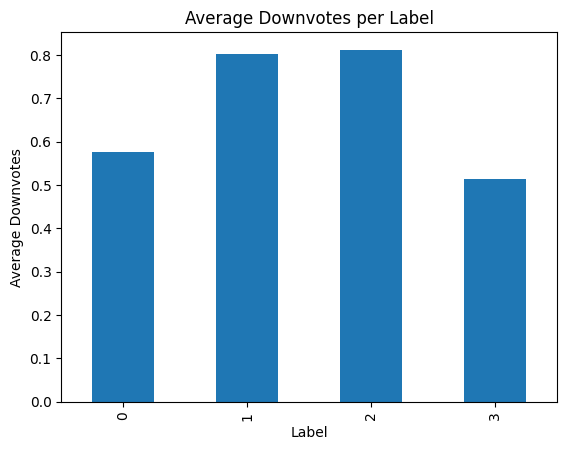

In [8]:
# Average downvotes per label
train.groupby('label')['downvote'].mean().plot.bar()

plt.title("Average Downvotes per Label")
plt.xlabel("Label")
plt.ylabel("Average Downvotes")
plt.show()

**Insights**
- The graph shows average downvotes for each label.
- Label 2 has the highest downvotes, so it gets more negative feedback.
- Label 1 also has high downvotes, slightly less than label 2.
- Label 0 has moderate downvotes.
- Label 3 has the lowest downvotes, meaning least negative feedback.
- This means some labels receive more criticism than others.

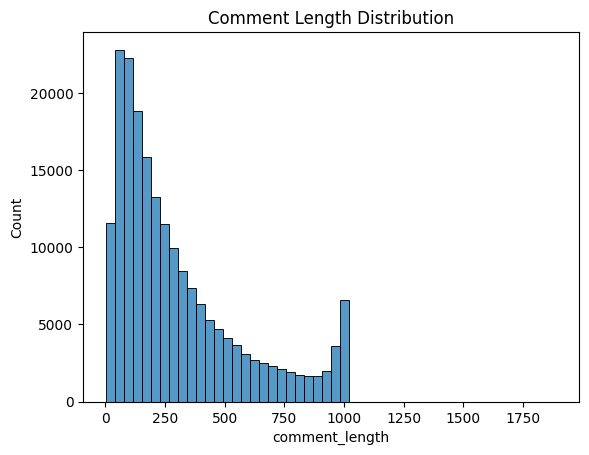

count    198000.000000
mean        302.909379
std         266.441732
min           1.000000
25%         102.000000
50%         211.000000
75%         419.000000
max        1892.000000
Name: comment_length, dtype: float64

In [9]:
# Comment Length Distribution

train['comment_length'] = train['comment'].astype(str).apply(len)

sns.histplot(train['comment_length'], bins=50)
plt.title("Comment Length Distribution")
plt.show()
train['comment_length'].describe()

**Insights**
- Most comments are short to medium length, mainly between 0 and 300 words.
- The average comment length is around 303 words.
- Half of the comments are below 211 words, so most are not very long.
- There are some very long comments (up to 1892 words), but they are rare.
- The graph is right-skewed, meaning many short comments and few long ones.
- This shows that users usually write short comments, with few long detailed ones.

label
0    295.897279
1    335.709700
2    316.893418
3    194.171695
Name: comment_length, dtype: float64


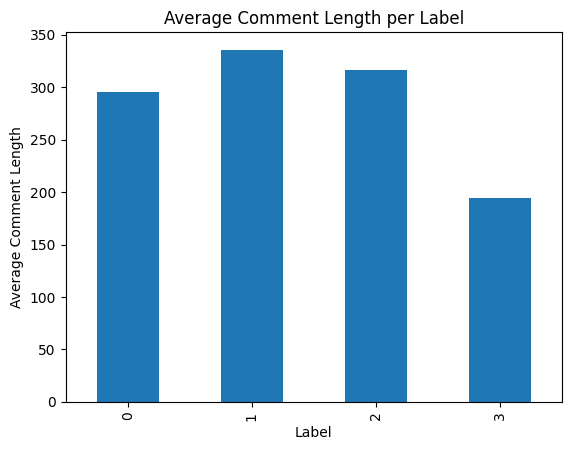

In [10]:
# Average comment length per label
avg_length = train.groupby('label')['comment_length'].mean()

print(avg_length)

avg_length.plot(kind='bar')

plt.title("Average Comment Length per Label")
plt.xlabel("Label")
plt.ylabel("Average Comment Length")

plt.show()

**Insights**
- The graph shows average comment length for each label.
- Label 1 has the longest comments (around 336 words).
- Label 2 also has long comments, slightly less than label 1.
- Label 0 has medium-length comments.
- Label 3 has the shortest comments (around 194 words).
- This means different labels have different writing patterns, some are more detailed while others are shorter.

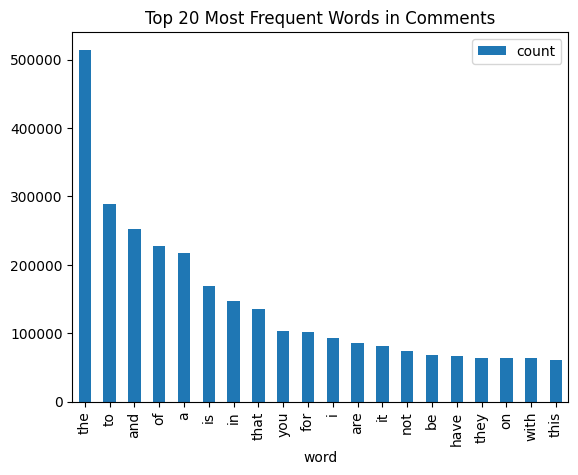

In [11]:
#Top 20 Most Frequent Words in Comments
from collections import Counter

words = ' '.join(train['comment'].astype(str)).lower().split()
top_words = Counter(words).most_common(20)

pd.DataFrame(top_words, columns=['word','count']).plot.bar(x='word', y='count')
plt.title("Top 20 Most Frequent Words in Comments")
plt.show()

**Insights**
- The graph shows the most common words in comments.
- Words like “the”, “to”, “and”, “of” appear the most.
- These are common stopwords, not meaningful for understanding content.
- Important insight is that raw text contains many unnecessary words.
- This means we need text cleaning (removing stopwords) before modeling.

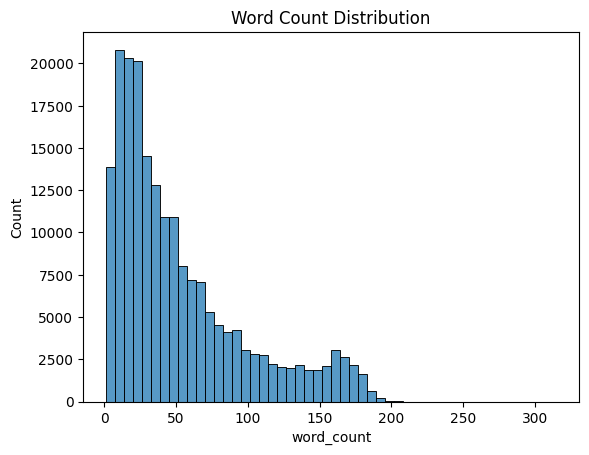

count    198000.000000
mean         52.396990
std          45.770215
min           1.000000
25%          18.000000
50%          37.000000
75%          73.000000
max         315.000000
Name: word_count, dtype: float64

In [12]:
# Word Count Distribution

train['word_count'] = train['comment'].astype(str).str.split().str.len()

sns.histplot(train['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

train['word_count'].describe()

**Insights**
- Most comments have small word counts, mainly between 0 and 60 words.
- The average word count is around 52 words.
- Half of the comments are below 37 words, so most are short.
- A few comments go up to 300+ words, but they are rare.
- The graph is right-skewed, meaning many short comments and few long ones.
- This shows users usually write short comments rather than long ones.

In [13]:
# Numerical Features Summary
num_cols = ['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2']

train[num_cols].describe()

,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212
std,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000
75%,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000
max,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000


In [14]:
# Categorical Features Distribution

cat_cols = ['race', 'religion', 'gender']

for col in cat_cols:
    print(f"\n{col} value counts:")
    print(train[col].value_counts())


race value counts:
race
none      39682
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64

religion value counts:
religion
none         38249
christian     7191
muslim        4930
jewish        1244
other          547
atheist        219
buddhist       100
hindu           97
Name: count, dtype: int64

gender value counts:
gender
none           36161
female          8037
male            7549
transgender      622
other            208
Name: count, dtype: int64


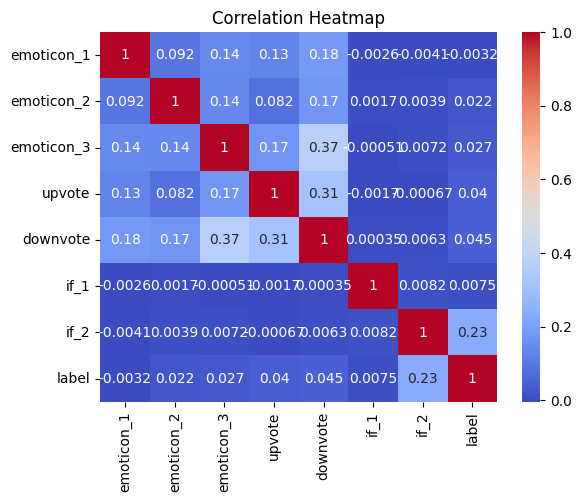

In [15]:
# Correlation Heatmap
num_cols = ['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2','label']

sns.heatmap(train[num_cols].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

**Insights**
- The heatmap shows relationship (correlation) between features.
- Most values are close to 0, which means weak or no strong relationship between variables.
- upvote and downvote have a moderate positive relation (0.31)
meaning posts with more upvotes can also get more downvotes.
- emoticon_3 and downvote show a slightly higher relation (0.37)
meaning this emoticon may be linked to more negative feedback.
- The label has very low correlation with most features
meaning no single feature strongly explains the label.
- if_2 has a small relation with label (0.23), but still not strong.

# Section 4: Data Cleaning & Feature Engineering

In [16]:
# Handle missing values
train['comment'] = train['comment'].fillna('')
test['comment'] = test['comment'].fillna('')

In [17]:
#Text cleaning
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

train['clean_comment'] = train['comment'].apply(clean_text)
test['clean_comment'] = test['comment'].apply(clean_text)

**Insights**
- The code cleans text data to make it uniform and ready for analysis.
- It converts all text to lowercase, so words like “Hello” and “hello” are treated the same.
- It removes links (URLs), which are not useful for meaning.
- It removes special characters and numbers, keeping only letters.
- It removes extra spaces, making text clean and neat.
- A new column clean_comment is created with the processed text.
- This step helps improve model accuracy by removing noise from text.

In [18]:
# Feature Engineering

# length of comment
train['comment_len'] = train['clean_comment'].apply(len)
test['comment_len'] = test['clean_comment'].apply(len)

# number of words
train['word_count'] = train['clean_comment'].apply(lambda x: len(x.split()))
test['word_count'] = test['clean_comment'].apply(lambda x: len(x.split()))

# number of exclamation marks
train['exclaim_count'] = train['comment'].apply(lambda x: x.count('!'))
test['exclaim_count'] = test['comment'].apply(lambda x: x.count('!'))

# number of question marks
train['question_count'] = train['comment'].apply(lambda x: x.count('?'))
test['question_count'] = test['comment'].apply(lambda x: x.count('?'))


**Insights**
- New features are created from text to help the model understand data better.
- comment_len stores length of the comment (number of characters).
- word_count stores number of words in each comment.
- exclaim_count counts how many “!” are used, showing strong emotions.
- question_count counts how many “?” are used, showing questions or doubt.

New features like comment length, word count, and punctuation counts are created to capture writing patterns and improve model performance.

# Section 5: Train Validation Split

In [19]:
X = train['clean_comment']
y = train['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Val size:", len(X_val))

Train size: 158400
Val size: 39600


**Insights**
- The data is split into training and validation sets.
- X contains input text (cleaned comments), and y contains labels.
- 80% data is used for training (158,400 samples).
- 20% data is used for validation (39,600 samples).
- stratify=y ensures same label distribution in both sets.
- random_state=42 makes the split consistent and reproducible.

The dataset is split into training and validation sets with stratification to maintain class balance, ensuring proper model training and evaluation.

# Section 6: TF-IDF Vectorization

In [20]:
# Word-level TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    analyzer='word'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(test['clean_comment'])

**Insights**
- This step converts text into numerical form using TF-IDF so the model can understand it.
- max_features=10000 keeps only the top 10,000 important words.
- ngram_range=(1,2) uses single words and pairs of words for better meaning.
- min_df=3 removes rare words that appear very few times.
- max_df=0.95 removes very common words (like stopwords).
- sublinear_tf=True reduces the impact of very frequent words.
- fit_transform is applied on training data to learn vocabulary.
- transform is used on validation and test data using the same learned features.

TF-IDF converts text into numerical features by giving importance to meaningful words while ignoring very common and very rare words, enabling the model to process text data.

In [21]:
# Character-level TF-IDF

tfidf_char = TfidfVectorizer(
    analyzer='char_wb',
    max_features=8000,
    ngram_range=(3, 4),
    sublinear_tf=True
)

X_train_char = tfidf_char.fit_transform(X_train)
X_val_char   = tfidf_char.transform(X_val)
X_test_char  = tfidf_char.transform(test['clean_comment'])

**Insights:**

This code creates character-level TF-IDF features by breaking text into small character n-grams (3 to 4 letters). It helps capture spelling variations and sub-word patterns, which improves performance in text classification tasks like toxic comment detection. The model is trained on training data and then applied consistently to validation and test sets.

# Section 7: Numerical features selection

In [22]:
num_features = [
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'upvote', 'downvote',
    'if_1', 'if_2',
    'comment_len', 'word_count',
    'exclaim_count', 'question_count'
]

**Insights**
- This step selects important numerical features for the model.
- These features capture user behavior, emotions, and writing style.

This step selects important numerical features that capture engagement, emotions, and writing patterns to improve model performance.

# Section 8: Feature Scaling

In [23]:
scaler = StandardScaler()

X_num = scaler.fit_transform(train[num_features])
X_num_test = scaler.transform(test[num_features])

print("Numerical features scaled")

Numerical features scaled


**Insights**
- This step scales numerical features using StandardScaler.
- It converts values so they have mean = 0 and standard deviation = 1.
- This makes all features on the same scale, so no feature dominates.
- fit_transform is used on training data to learn scaling parameters.
- transform is used on test data using the same scaling.

Feature scaling standardizes numerical data so all features are on the same scale, which improves model performance and stability.

# Section 9: Feature Combination

In [24]:
# numerical features for train/val splits
X_train_num = csr_matrix(X_num[X_train.index])
X_val_num   = csr_matrix(X_num[X_val.index])

# combine train/val (word TF-IDF + char TF-IDF + numerical)
X_train_final = hstack([X_train_tfidf, X_train_char, X_train_num])
X_val_final   = hstack([X_val_tfidf,   X_val_char,   X_val_num])

# full dataset (for final model training)
X_tfidf_full = tfidf.transform(train['clean_comment'])
X_char_full  = tfidf_char.transform(train['clean_comment'])
X_num_full   = csr_matrix(scaler.transform(train[num_features]))

X_combined = hstack([X_tfidf_full, X_char_full, X_num_full])
y = train['label']

print("Train shape:", X_train_final.shape)
print("Full data shape:", X_combined.shape)

Train shape: (158400, 18011)
Full data shape: (198000, 18011)


**Insights**
- This step combines text features and numerical features into one dataset.
- TF-IDF features represent text information.
- Numerical features represent extra information like upvotes, length, etc.
- hstack is used to merge both types of features horizontally.
- Separate datasets are created for:
   - Training (X_train_final)
   - Validation (X_val_final)
   - Full dataset (X_combined)

This step combines text features and numerical features into a single dataset so the model can learn from both content and additional information together.

# Section 10: Model Training

In this step, multiple machine learning models are trained and compared.
- Models used:
  - Logistic Regression
  - Naive Bayes
  - LightGBM


In [25]:
#Model 1: Logistic Regression (baseline model)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# initialize Model
model_lr = LogisticRegression(max_iter=1000)

# Train Model
model_lr.fit(X_train_final, y_train)

# Predictions
pred_lr = model_lr.predict(X_val_final)

#evaluation
acc_lr = accuracy_score(y_val, pred_lr)

print("Logistic Regression:", acc_lr)

Logistic Regression: 0.9052777777777777


**Insight:**

Logistic Regression is a simple baseline model. It learns basic patterns from the data and predicts classes. It is fast and works well with text features, so it is a good starting point to compare other models.

In [26]:
# Model 2: LightGBM

import lightgbm as lgb
from sklearn.metrics import accuracy_score

# initialize model
lgbm_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.08,
    num_leaves=127,
    class_weight='balanced',
    random_state=42
)

# Train model
lgbm_model.fit(X_train_final, y_train)

# Predictions
pred_lgb = lgbm_model.predict(X_val_final)

# Evaluation
acc_lgb = accuracy_score(y_val, pred_lgb)

print("LightGBM Accuracy:", acc_lgb)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 28.658658 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3229030
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 18011
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.9177525252525253


**Insights:**

LightGBM is a powerful gradient boosting model - it builds many decision trees one after another, each one correcting the mistakes of the previous one. We set `class_weight='balanced'` to handle the class imbalance we noticed earlier.

LightGBM is an advanced model that handles class imbalance and learns complex patterns, so it usually performs better than simple models.

In [27]:
# Model 3: Naive Bayes

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# initialize model
nb_model = MultinomialNB(alpha=1.0)

# Train model
nb_model.fit(X_train_tfidf, y_train)

# Predictions
nb_preds = nb_model.predict(X_val_tfidf)

# Evaluation
nb_acc = accuracy_score(y_val, nb_preds)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.7013131313131313


**Insights**
- Naive Bayes is a simple and fast model.
- It works especially well for text data (TF-IDF features).
- It assumes words are independent, which makes it efficient.
- It learns patterns based on word frequency.
- It is useful as a quick and strong baseline for text classification.

# Section 11: Model Comparison

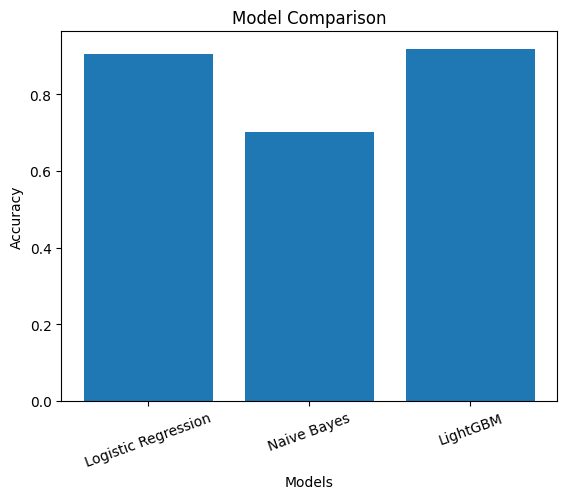

In [28]:
# Model Comparison

results = {
    "Logistic Regression": acc_lr,
    "Naive Bayes": nb_acc,
    "LightGBM": acc_lgb
}

models = ["Logistic Regression", "Naive Bayes", "LightGBM"]
scores = [acc_lr, nb_acc, acc_lgb]

plt.figure()
plt.bar(models, scores)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()

**Insights**
- Logistic Regression and LightGBM have almost same high accuracy (~90%).
- Naive Bayes has much lower accuracy (~53%).
- LightGBM performs better then all the models.


In [29]:
#Best Model
best_model = max(results, key=results.get)
print("Best Model:", best_model)

Best Model: LightGBM


**Insight:**
Overall, the best performing model is LightGBm model.

# Section 12: Hyperparameter Tuning (LightGBM)

In [30]:
from sklearn.model_selection import RandomizedSearchCV

# model
model = lgb.LGBMClassifier(random_state=42)

# parameters to try
params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50]
}

# apply Random Search
search = RandomizedSearchCV(
    model,
    params,
    n_iter=3,      
    cv=3            
)

# Train
search.fit(X_train_final, y_train)

# Check best result
print("Best Parameters:", search.best_params_)

# Test on validation data
preds = search.predict(X_val_final)
print("Accuracy:", accuracy_score(y_val, preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 20.793035 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2830570
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 18011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start training from score -3.589103


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 20.845917 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2825663
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 18011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154071
[LightGBM] [Info] Start training from score -3.589103


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 20.764861 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2830958
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 18011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154041
[LightGBM] [Info] Start training from score -3.589446


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 20.782782 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2830958
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 18011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154041
[LightGBM] [Info] Start training from score -3.589446


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 32.047621 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3229030
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 18011
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217
Best Parameters: {'num_leaves': 50, 'n_estimators': 200, 'learning_rate': 0.1}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9176515151515151


**Insights**
- This step uses RandomizedSearchCV to find the best parameters for LightGBM.
- It tries different values of:
    - number of trees (n_estimators)
    - learning rate
    - number of leaves
- It tests multiple combinations automatically.
- cv=3 means it uses 3-fold cross-validation for better evaluation.
- It selects the best parameter combination based on performance.
- This helps to improve model accuracy without manual tuning.

# Section 13: Final model

In [31]:
print("Training final model (LightGBM)")

final_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.08,
    class_weight='balanced',
    random_state=42
)

# Train on full dataset
final_model.fit(X_combined, y)

print("Final model training completed")

Training final model (LightGBM)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 43.145069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3424966
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 18011
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Final model training completed


**Insights:**

- So I chose LightGBM because it captures non-linear patterns and gives better generalization after tuning and cross-validation.
- LightGBM becomes the best model overall. And thats why i choose LightGBM model for the final model.


# Section 14: Final predictions and submission file

In [32]:
# final predictions

# Prepare test data
X_test_tfidf = tfidf.transform(test['clean_comment'])
X_test_num = csr_matrix(X_num_test)

# Combine features
X_test_final = hstack([X_test_tfidf, X_test_char, X_test_num])

# Predict
test_preds = final_model.predict(X_test_final)

print("Predictions done")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Predictions done


**Insight:**
We apply the same feature preparation steps to the test data (TF-IDF + numerical scaling + combining), then run the final model to generate predictions

In [33]:
#genarting submission file

# Load sample submission
sample = pd.read_csv(f'{DATA_PATH}/Sample.csv')

# Replace label column with predictions
sample['label'] = test_preds

# Save file
sample.to_csv("submission.csv", index=False)

print("Submission saved")
sample.head()

Submission saved


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
